### Install dependencies

This notebook requires a dependency which can be installed with the following command `pip install open-bus-stride-client`.

You can also launch it online at [this URL](https://mybinder.org/v2/gh/hasadna/open-bus-stride-client/HEAD?labpath=notebooks%2Fload%20gtfs%20timetable%20to%20pandas%20dataframe.ipynb), when launching online the dependencies are already installed.


In [1]:
!pip install open-bus-stride-client


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import datetime
from dateutil import tz

pd.options.display.max_columns = 1000
pd.options.display.max_colwidth = 1000

import stride

### Find a route to investigate

First, let's find a route (`line_ref`) to investigate. As each line (`route_short_name`) could have few routes (mainly one for each driving direction), we first take a look on the `gtfs_routes` for picking our route.  

Let's look for line number `15` (Egged, Jerusalem).

In [3]:
pd.DataFrame(stride.get('/gtfs_routes/list', {'route_short_name':5,
                                                            # 'agency_name': 'אגד',
                                                            'agency_name': 'דן',
                                                            # 'route_long_name_contains': 'ת״א',
                                              'date_from': '2026-07-29',
                                              'date_to':  '2026-07-30'}))

,id,date,line_ref,operator_ref,route_short_name,route_long_name,route_mkt,route_direction,route_alternative,agency_name,route_type
0,9334460,2026-07-29,2259,5,5,ת. רכבת תל אביב סבידור/על פרשת דרכים-תל אביב יפו<->מסוף הלוחמים/משרד הרישוי-תל אביב יפו-10,25005,1,0,דן,3
1,9334461,2026-07-29,2261,5,5,משרד הרישוי/הלוחמים-חולון<->ת. רכבת תל אביב - סבידור/הורדה-תל אביב יפו-20,25005,2,0,דן,3
2,9334462,2026-07-29,2262,5,5,אזור התעשייה-בני ברק<->בית העלמין/חזון אי''ש-בני ברק-10,26005,1,0,דן,3
3,9334463,2026-07-29,2263,5,5,בית העלמין/חזון אי''ש-בני ברק<->אזור התעשייה-בני ברק-20,26005,2,0,דן,3
4,9338796,2026-07-29,32055,5,5,אזור התעשייה-בני ברק<->אזור התעשייה-בני ברק-11,26005,1,1,דן,3
5,9340293,2026-07-30,2259,5,5,ת. רכבת תל אביב סבידור/על פרשת דרכים-תל אביב יפו<->מסוף הלוחמים/משרד הרישוי-תל אביב יפו-10,25005,1,0,דן,3
6,9340294,2026-07-30,2261,5,5,משרד הרישוי/הלוחמים-חולון<->ת. רכבת תל אביב - סבידור/הורדה-תל אביב יפו-20,25005,2,0,דן,3
7,9340295,2026-07-30,2262,5,5,אזור התעשייה-בני ברק<->בית העלמין/חזון אי''ש-בני ברק-10,26005,1,0,דן,3
8,9340296,2026-07-30,2263,5,5,בית העלמין/חזון אי''ש-בני ברק<->אזור התעשייה-בני ברק-20,26005,2,0,דן,3
9,9344642,2026-07-30,32055,5,5,אזור התעשייה-בני ברק<->אזור התעשייה-בני ברק-11,26005,1,1,דן,3


This line as 2 routes (`line_ref`), let's pick `14206` route and get its timetable (note GTFS is the planned timetable, not the actual).

### Get GTFS Timetable (Documentation: https://open-bus-stride-api.hasadna.org.il/docs#/)

We use the stride iterate method to efficiently iterate over a possibly long list of results.

Behind the scenes it uses the offset/limit parameters so you don't have to worry about it.

We pass on the iterator directly on to Pandas to create a DataFrame.

In [4]:
gtfs_timetable = pd.DataFrame(stride.iterate('/route_timetable/list', {
    # 'line_refs': '12406',
    # 'line_refs': '4358',
    'line_refs': '32055',
    'planned_start_time_date_from': '2026-07-29T08:00:00+03:00',
    'planned_start_time_date_to': '2026-07-30T08:00:00+03:00',
    'order_by': 'gtfs_line_start_time, planned_arrival_time'
}, limit=10000))

gtfs_timetable.shape

(100, 9)

In [5]:
gtfs_timetable

,id,name,city,lon,lat,planned_arrival_time,gtfs_line_ref,gtfs_line_start_time,gtfs_ride_id
0,47043712,אזור התעשייה,בני ברק,34.827959,32.102516,2026-07-29 05:10:00+00:00,32055,2026-07-29 05:10:00+00:00,152179308
1,47028844,קניון איילון/מבצע קדש,רמת גן,34.827845,32.101244,2026-07-29 05:11:46+00:00,32055,2026-07-29 05:10:00+00:00,152179308
2,47028933,קניון איילון/דרך אבא הלל,רמת גן,34.827472,32.098809,2026-07-29 05:12:50+00:00,32055,2026-07-29 05:10:00+00:00,152179308
3,47046388,הירקון/בר כוכבא,בני ברק,34.823594,32.095394,2026-07-29 05:15:51+00:00,32055,2026-07-29 05:10:00+00:00,152179308
4,47046384,הירקון/הרב ישראל אבו חצירא,בני ברק,34.829591,32.097138,2026-07-29 05:17:08+00:00,32055,2026-07-29 05:10:00+00:00,152179308
...,...,...,...,...,...,...,...,...,...
95,47029584,הרב קובלסקי/הרב נורוק,בני ברק,34.842692,32.097892,2026-07-29 06:07:59+00:00,32055,2026-07-29 05:55:00+00:00,152181124
96,47039638,הרב נורוק/רבי גניחובסקי,בני ברק,34.843398,32.098488,2026-07-29 06:08:26+00:00,32055,2026-07-29 05:10:00+00:00,152179308
97,47029543,בירנבוים/הרב עוזיאל,בני ברק,34.840713,32.071681,2026-07-29 06:08:31+00:00,32055,2026-07-29 05:30:00+00:00,152179309
98,47039636,הרב נורוק/אברבנאל,בני ברק,34.842551,32.095938,2026-07-29 06:08:59+00:00,32055,2026-07-29 05:55:00+00:00,152181124


Note that in this example the `planned_start_time_date_from` and the `planned_start_time_date_to` are both equal to a spesific ride start time. You can also pass a time window of few minutes/hours to (potentially) get more than one ride timetable for the same route (`line_ref`).

The date columns are on UTC timezone, let's localize the dates to Israel timezone.

In [6]:
def localize_dates(data, dt_columns = None):
    if dt_columns is None:
        dt_columns=[]
    
    data = data.copy()
    
    for c in dt_columns:
        data[c] = pd.to_datetime(data[c]).dt.tz_convert('Israel')
    
    return data

In [7]:
dt_columns = ['gtfs_line_start_time','planned_arrival_time']

gtfs_timetable = localize_dates(gtfs_timetable, dt_columns)

In [8]:
gtfs_timetable

,id,name,city,lon,lat,planned_arrival_time,gtfs_line_ref,gtfs_line_start_time,gtfs_ride_id
0,47043712,אזור התעשייה,בני ברק,34.827959,32.102516,2026-07-29 08:10:00+03:00,32055,2026-07-29 08:10:00+03:00,152179308
1,47028844,קניון איילון/מבצע קדש,רמת גן,34.827845,32.101244,2026-07-29 08:11:46+03:00,32055,2026-07-29 08:10:00+03:00,152179308
2,47028933,קניון איילון/דרך אבא הלל,רמת גן,34.827472,32.098809,2026-07-29 08:12:50+03:00,32055,2026-07-29 08:10:00+03:00,152179308
3,47046388,הירקון/בר כוכבא,בני ברק,34.823594,32.095394,2026-07-29 08:15:51+03:00,32055,2026-07-29 08:10:00+03:00,152179308
4,47046384,הירקון/הרב ישראל אבו חצירא,בני ברק,34.829591,32.097138,2026-07-29 08:17:08+03:00,32055,2026-07-29 08:10:00+03:00,152179308
...,...,...,...,...,...,...,...,...,...
95,47029584,הרב קובלסקי/הרב נורוק,בני ברק,34.842692,32.097892,2026-07-29 09:07:59+03:00,32055,2026-07-29 08:55:00+03:00,152181124
96,47039638,הרב נורוק/רבי גניחובסקי,בני ברק,34.843398,32.098488,2026-07-29 09:08:26+03:00,32055,2026-07-29 08:10:00+03:00,152179308
97,47029543,בירנבוים/הרב עוזיאל,בני ברק,34.840713,32.071681,2026-07-29 09:08:31+03:00,32055,2026-07-29 08:30:00+03:00,152179309
98,47039636,הרב נורוק/אברבנאל,בני ברק,34.842551,32.095938,2026-07-29 09:08:59+03:00,32055,2026-07-29 08:55:00+03:00,152181124


In [9]:
gtfs_timetable[['gtfs_line_ref','gtfs_line_start_time', 'city','name','planned_arrival_time', 'lon','lat']]

,gtfs_line_ref,gtfs_line_start_time,city,name,planned_arrival_time,lon,lat
0,32055,2026-07-29 08:10:00+03:00,בני ברק,אזור התעשייה,2026-07-29 08:10:00+03:00,34.827959,32.102516
1,32055,2026-07-29 08:10:00+03:00,רמת גן,קניון איילון/מבצע קדש,2026-07-29 08:11:46+03:00,34.827845,32.101244
2,32055,2026-07-29 08:10:00+03:00,רמת גן,קניון איילון/דרך אבא הלל,2026-07-29 08:12:50+03:00,34.827472,32.098809
3,32055,2026-07-29 08:10:00+03:00,בני ברק,הירקון/בר כוכבא,2026-07-29 08:15:51+03:00,34.823594,32.095394
4,32055,2026-07-29 08:10:00+03:00,בני ברק,הירקון/הרב ישראל אבו חצירא,2026-07-29 08:17:08+03:00,34.829591,32.097138
...,...,...,...,...,...,...,...
95,32055,2026-07-29 08:55:00+03:00,בני ברק,הרב קובלסקי/הרב נורוק,2026-07-29 09:07:59+03:00,34.842692,32.097892
96,32055,2026-07-29 08:10:00+03:00,בני ברק,הרב נורוק/רבי גניחובסקי,2026-07-29 09:08:26+03:00,34.843398,32.098488
97,32055,2026-07-29 08:30:00+03:00,בני ברק,בירנבוים/הרב עוזיאל,2026-07-29 09:08:31+03:00,34.840713,32.071681
98,32055,2026-07-29 08:55:00+03:00,בני ברק,הרב נורוק/אברבנאל,2026-07-29 09:08:59+03:00,34.842551,32.095938


### Plot the planned route on a map

We take a single ride (`gtfs_ride_id`) from the timetable, sort its stops by `planned_arrival_time`, and draw the route as a line colored by time (using a `LineCollection` so each segment gets its own color), with `'o'` markers at each planned stop.

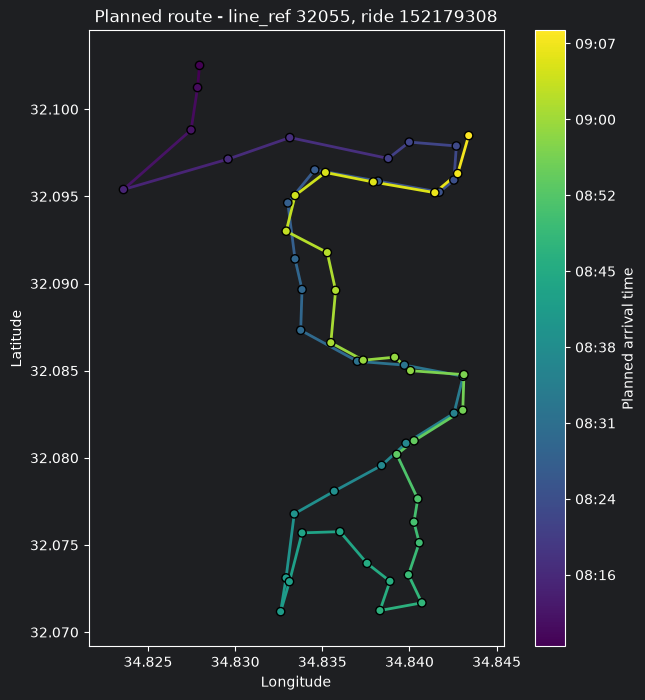

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
import numpy as np

# a single ride's timetable is one continuous trip - pick the first ride_id so the
# route line traces one sequential path instead of jumbling several trips together
ride_id = gtfs_timetable['gtfs_ride_id'].iloc[0]
ride = gtfs_timetable[gtfs_timetable['gtfs_ride_id'] == ride_id].sort_values('planned_arrival_time')

lon = ride['lon'].to_numpy()
lat = ride['lat'].to_numpy()
times = mdates.date2num(ride['planned_arrival_time'])

points = np.column_stack([lon, lat]).reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

fig, ax = plt.subplots(figsize=(8, 8))

norm = plt.Normalize(times.min(), times.max())
lc = LineCollection(segments, cmap='viridis', norm=norm, linewidth=2)
lc.set_array(times[:-1])
ax.add_collection(lc)

ax.scatter(lon, lat, c=times, cmap='viridis', norm=norm, marker='o', edgecolor='black', zorder=3)

ax.set_xlim(lon.min() - 0.002, lon.max() + 0.002)
ax.set_ylim(lat.min() - 0.002, lat.max() + 0.002)
ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f"Planned route - line_ref {ride['gtfs_line_ref'].iloc[0]}, ride {ride_id}")

cbar = fig.colorbar(lc, ax=ax)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=ride['planned_arrival_time'].dt.tz))
cbar.set_label('Planned arrival time')

plt.show()

### Plot the route on an actual map of Israel

Same idea as above, but rendered on a real interactive map using [folium](https://python-visualization.github.io/folium/) (Leaflet + OpenStreetMap tiles — no API key required, unlike Google Maps tiles which need a billed Google Cloud API key). Route segments and stop markers are colored by elapsed time using a viridis-style gradient; click a stop marker to see its name and planned arrival time.

Requires `pip install folium branca`.

In [12]:
import folium
import branca.colormap as cm

start_time = ride['planned_arrival_time'].iloc[0]
elapsed_min = (ride['planned_arrival_time'] - start_time).dt.total_seconds() / 60

route_map = folium.Map(location=[ride['lat'].mean(), ride['lon'].mean()], zoom_start=14, tiles='OpenStreetMap')

colormap = cm.LinearColormap(
    colors=['#440154', '#31688e', '#35b779', '#fde725'],  # viridis-style gradient
    vmin=elapsed_min.min(), vmax=elapsed_min.max()
)
colormap.caption = f"Minutes since {start_time.strftime('%H:%M')}"

coords = list(zip(ride['lat'], ride['lon']))

for (lat1, lon1), (lat2, lon2), t in zip(coords[:-1], coords[1:], elapsed_min.iloc[:-1]):
    folium.PolyLine([(lat1, lon1), (lat2, lon2)], color=colormap(t), weight=5, opacity=0.9).add_to(route_map)

for (lat, lon), t, name, arr in zip(coords, elapsed_min, ride['name'], ride['planned_arrival_time']):
    folium.CircleMarker(
        location=(lat, lon),
        radius=6,
        color='black',
        weight=1,
        fill=True,
        fill_color=colormap(t),
        fill_opacity=1.0,
        popup=f"{name} — {arr.strftime('%H:%M')}",
    ).add_to(route_map)

colormap.add_to(route_map)